## Importing Data Set

In [3]:
import pandas as pd
print("Pandas version:", pd.__version__)

Pandas version: 2.3.3


In [7]:
import pandas as pd

df = pd.read_csv('online_retail_II.csv', encoding='latin-1')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (1067371, 8)

Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

First 5 rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## Data cleaning

In [8]:
# Check nulls
print("Null values:\n", df.isnull().sum())

# Remove rows with no Customer ID
df = df.dropna(subset=['Customer ID'])

# Remove cancelled orders (Invoice starting with C)
df = df[~df['Invoice'].astype(str).str.startswith('C')]

# Remove negative quantities and prices
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]

# Fix data types
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Customer ID'] = df['Customer ID'].astype(int)

# Add Revenue column
df['Revenue'] = df['Quantity'] * df['Price']

print("\nAfter cleaning:")
print("Shape:", df.shape)
print("\nSample:")
df.head()

Null values:
 Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

After cleaning:
Shape: (805549, 9)

Sample:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


## Calculating RFM Scores

In [9]:
import datetime as dt

# Reference date — one day after last invoice date
reference_date = df['InvoiceDate'].max() + dt.timedelta(days=1)
print("Reference date:", reference_date)

# Calculate RFM values for each customer
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'Invoice': 'nunique',                                        # Frequency
    'Revenue': 'sum'                                             # Monetary
}).reset_index()

# Rename columns
rfm.columns = ['Customer ID', 'Recency', 'Frequency', 'Monetary']

print("\nRFM Table:")
print(rfm.shape)
rfm.head()

Reference date: 2011-12-10 12:50:00

RFM Table:
(5878, 4)


,Customer ID,Recency,Frequency,Monetary
0,12346,326,12,77556.46
1,12347,2,8,5633.32
2,12348,75,5,2019.40
3,12349,19,4,4428.69
4,12350,310,1,334.40


## Scoring Each Customer 1  to 5

In [10]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, 
                          labels=[5,4,3,2,1])

rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, 
                          labels=[1,2,3,4,5])

rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, 
                          labels=[1,2,3,4,5])

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + \
                   rfm['F_Score'].astype(str) + \
                   rfm['M_Score'].astype(str)

print("RFM Scores added!")
rfm.head(10)

RFM Scores added!


,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346,326,12,77556.46,2,5,5,255
1,12347,2,8,5633.32,5,4,5,545
2,12348,75,5,2019.40,3,4,4,344
3,12349,19,4,4428.69,5,3,5,535
4,12350,310,1,334.40,2,1,2,212
5,12351,375,1,300.93,2,1,2,212
6,12352,36,10,2849.84,4,5,4,454
7,12353,204,2,406.76,2,2,2,222
8,12354,232,1,1079.40,2,1,3,213
9,12355,214,2,947.61,2,2,3,223


## Assigning segment labels

In [12]:
def assign_segment(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])
    
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r >= 3 and f >= 2 and m >= 2:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

print("Segments assigned!")
print(rfm['Segment'].value_counts())

Segments assigned!
Segment
Champions              1300
Lost                   1275
Loyal Customers        1134
Others                  755
At Risk                 615
New Customers           443
Potential Loyalists     356
Name: count, dtype: int64


## Visualize the segments

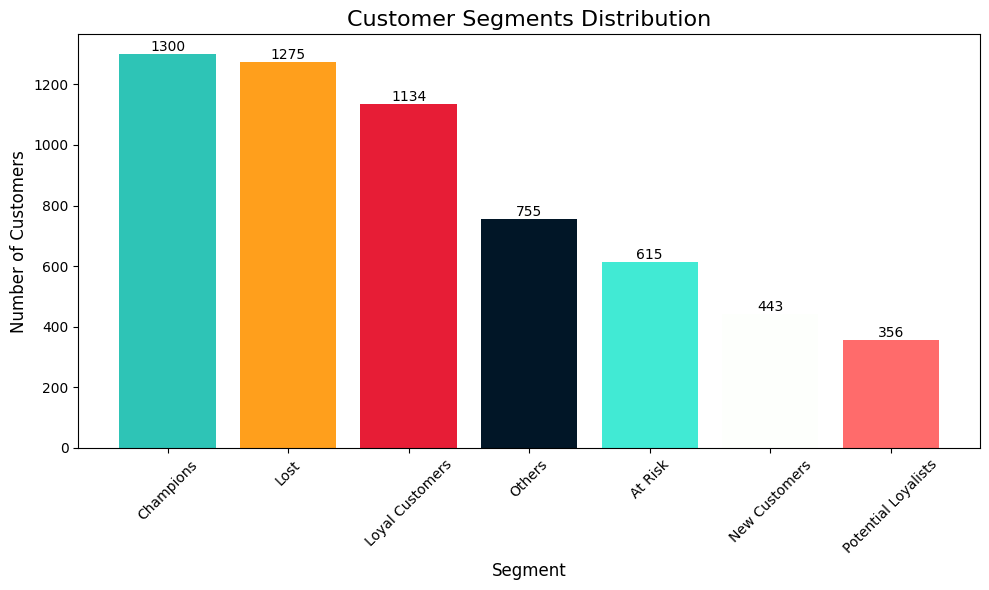

Chart saved!


In [20]:
import matplotlib.pyplot as plt

# Segment distribution
segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(10, 6))
colors = ['#2EC4B6','#FF9F1C','#E71D36','#011627',
          '#41EAD4','#FDFFFC','#FF6B6B']

plt.bar(segment_counts.index, segment_counts.values, color=colors)
plt.title('Customer Segments Distribution', fontsize=16)
plt.xlabel('Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=45)

for i, v in enumerate(segment_counts.values):
    plt.text(i, v + 10, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('segment_distribution.png', dpi=150)
plt.show()
print("Chart saved!")

## Revenue by Segment

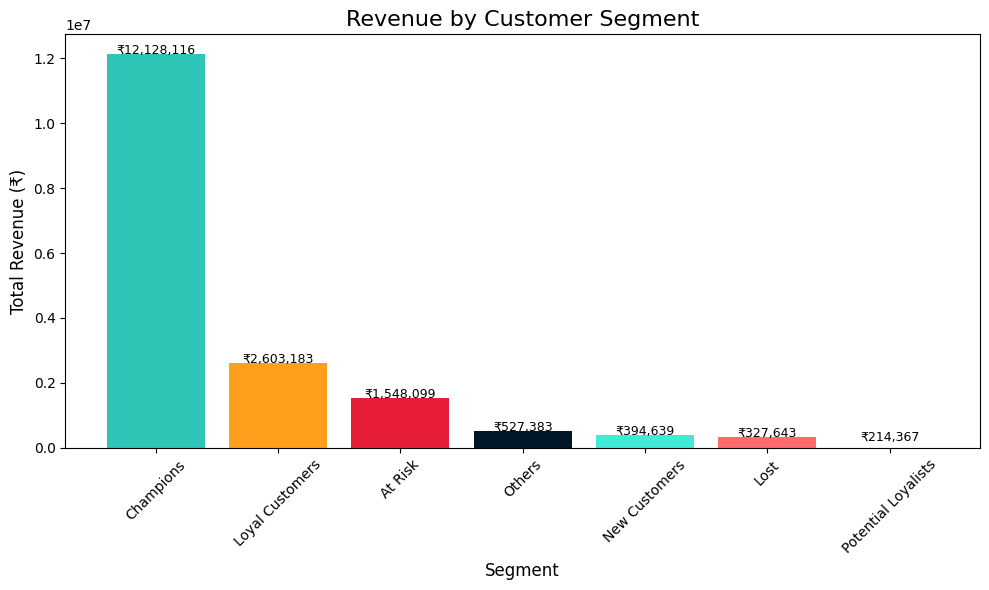

Chart saved!


In [21]:
# Revenue by segment
segment_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#2EC4B6','#FF9F1C','#E71D36','#011627',
          '#41EAD4','#FF6B6B','#FDFFFC']

plt.bar(segment_revenue.index, segment_revenue.values, color=colors)
plt.title('Revenue by Customer Segment', fontsize=16)
plt.xlabel('Segment', fontsize=12)
plt.ylabel('Total Revenue (₹)', fontsize=12)
plt.xticks(rotation=45)

for i, v in enumerate(segment_revenue.values):
    plt.text(i, v + 1000, f'₹{v:,.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('segment_revenue.png', dpi=150)
plt.show()
print("Chart saved!")

## RFM Heatmap

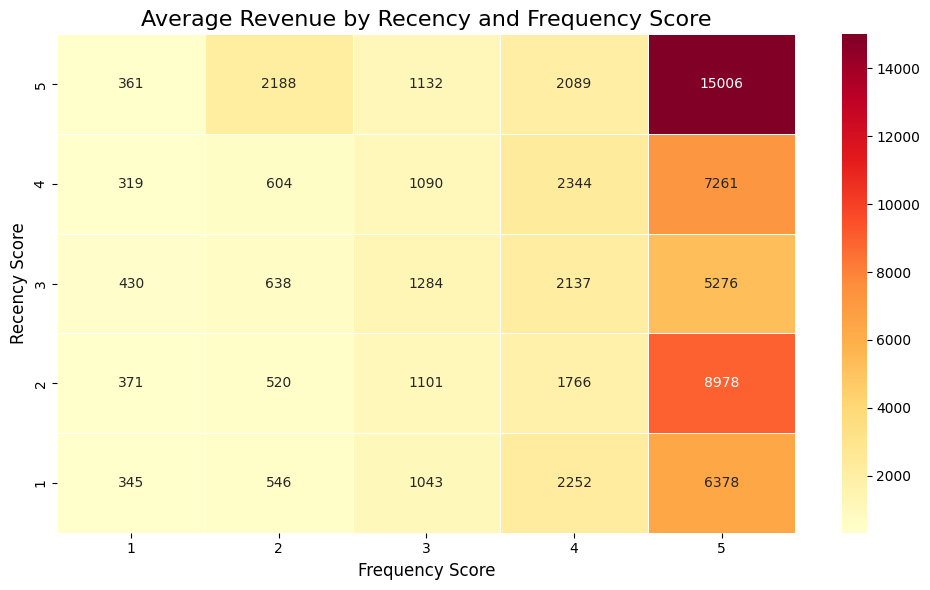

Heatmap saved!


In [17]:
import seaborn as sns

# Create pivot table for heatmap
rfm_pivot = rfm.groupby(['R_Score', 'F_Score'], observed = False)['Monetary'].mean().unstack()

plt.figure(figsize=(10, 6))
sns.heatmap(rfm_pivot, 
            annot=True, 
            fmt='.0f',
            cmap='YlOrRd',
            linewidths=0.5)

plt.title('Average Revenue by Recency and Frequency Score', fontsize=16)
plt.xlabel('Frequency Score', fontsize=12)
plt.ylabel('Recency Score', fontsize=12)

plt.tight_layout()
plt.savefig('rfm_heatmap.png', dpi=150)
plt.show()
print("Heatmap saved!")

In [18]:
# Save final RFM table to CSV
rfm.to_csv('rfm_segments.csv', index=False)
print("RFM table saved!")
print("\nFinal summary:")
print(f"Total Customers: {len(rfm)}")
print(f"\nSegment Distribution:")
print(rfm['Segment'].value_counts())
print(f"\nRevenue by Segment:")
print(rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False).round(2))

RFM table saved!

Final summary:
Total Customers: 5878

Segment Distribution:
Segment
Champions              1300
Lost                   1275
Loyal Customers        1134
Others                  755
At Risk                 615
New Customers           443
Potential Loyalists     356
Name: count, dtype: int64

Revenue by Segment:
Segment
Champions              12128115.56
Loyal Customers         2603183.47
At Risk                 1548098.81
Others                   527382.84
New Customers            394638.61
Lost                     327643.25
Potential Loyalists      214366.63
Name: Monetary, dtype: float64
